# AutoEncodeur simple configurable — MNIST

Ce notebook est organisé pour que vous puissiez expérimenter principalement en modifiant **une seule cellule de configuration**.

## Paramètres testables

- architecture `dense` ou `conv`
- dimension latente
- nombre et taille des couches cachées Dense
- filtres et strides Conv2D
- fonctions d'activation
- learning rate
- batch size
- nombre d'epochs
- optimiseur
- fonction de perte
- initialisation des poids
- normalisation des données

## Tâches

1. La compression et la décompression sont apprises naturellement pendant le forward pass.
2. Après l'entraînement, nous affichons quelques **points latents** avec leurs images originales et reconstruites.
3. Si `latent_dim == 2`, nous visualisons directement **l'espace latent 2D lui-même**.
4. Nous testons une génération expérimentale par échantillonnage du latent.

> Pour privilégier la visualisation directe, utilisez `latent_dim=2`.  
> Pour privilégier la qualité de reconstruction, testez par exemple `8`, `16` ou `32`.


## 1. Imports, configuration et classe `SimpleAutoencoder`

La cellule suivante contient toute la logique réutilisable.  
Vous ne devriez normalement pas avoir besoin de la modifier pour lancer vos expériences.


In [21]:
"""
AutoEncodeur simple MNIST configurable / tunable - TensorFlow/Keras

Le but de ce fichier est de pouvoir expérimenter en ne modifiant principalement
que l'objet CONFIG situé en bas du fichier.

Paramètres principaux que vous pouvez tuner :
- architecture        : "dense" ou "conv"
- latent_dim          : dimension de l'espace latent
- hidden_dims         : couches cachées pour l'architecture Dense
- hidden_activation   : activation des couches cachées
- latent_activation   : activation de la couche latente
- output_activation   : activation de sortie
- conv_filters        : nombre de filtres des couches Conv2D
- conv_strides        : strides de l'encodeur convolutionnel
- kernel_size         : taille des noyaux Conv2D
- kernel_initializer  : initialisation des poids
- learning_rate       : taux d'apprentissage
- batch_size          : taille des batchs
- epochs              : nombre d'epochs
- optimizer_name      : "adam", "sgd" ou "rmsprop"
- loss_name           : "mse" ou "binary_crossentropy"
- normalization       : "zero_one" ou "minus_one_one"

Tâches :
1. Apprentissage de la compression / décompression pendant le forward pass.
2. Après entraînement : affichage de quelques points latents et reconstructions.
3. Visualisation directe de l'espace latent lorsque latent_dim == 2.
4. Génération de nouvelles images par échantillonnage empirique du latent.

Installation :
    pip install tensorflow numpy matplotlib

Exécution :
    python autoencoder_tunable.py
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


# ============================================================
# 1. CONFIGURATION CENTRALISÉE
# ============================================================

@dataclass
class AutoencoderConfig:
    # "dense" ou "conv"
    architecture: str = "dense"
    latent_dim: int = 2
    hidden_dims: Tuple[int, ...] = (128, 32)

    # Activations
    # Exemples : "relu", "elu", "tanh", "leaky_relu", "linear"
    hidden_activation: str = "relu"
    latent_activation: str = "linear"
    output_activation: str = "sigmoid"
    leaky_relu_slope: float = 0.2

    # Architecture convolutionnelle
    # Exemple MNIST : 28 -> 14 -> 7 avec strides (2, 2)
    # On peut ajouter des couches avec stride=1 :
    # conv_filters=(32, 64, 64), conv_strides=(2, 2, 1)
    conv_filters: Tuple[int, ...] = (32, 64)
    conv_strides: Tuple[int, ...] = (2, 2)
    kernel_size: int = 3

    # Initialisation
    kernel_initializer: str = "glorot_uniform"

    # Apprentissage
    learning_rate: float = 1e-3
    batch_size: int = 256
    epochs: int = 200
    optimizer_name: str = "adam"
    loss_name: str = "mse"

    # Préparation des données
    # "zero_one"      : pixels dans [0, 1], sortie sigmoid recommandée
    # "minus_one_one" : pixels dans [-1, 1], sortie tanh recommandée
    normalization: str = "zero_one"

    # Reproductibilité / affichage
    seed: int = 42
    n_examples: int = 10
    n_generated_images: int = 16
    latent_grid_size: int = 20

    # Sorties
    output_dir: str = "outputs_autoencoder_mnist"


# ============================================================
# 2. AUTOENCODEUR CONFIGURABLE
# ============================================================

class SimpleAutoencoder:
    IMAGE_HEIGHT = 28
    IMAGE_WIDTH = 28
    IMAGE_CHANNELS = 1
    INPUT_DIM = IMAGE_HEIGHT * IMAGE_WIDTH

    def __init__(self, config: AutoencoderConfig):
        self.config = config
        self._validate_config()

        np.random.seed(config.seed)
        tf.random.set_seed(config.seed)

        self.output_dir = Path(config.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.encoder, self.decoder = self._build_models()
        self.optimizer = self._build_optimizer()
        self.loss_fn = tf.keras.losses.get(config.loss_name)

        self.history = []

    # --------------------------------------------------------
    # VALIDATION DE LA CONFIGURATION
    # --------------------------------------------------------

    def _validate_config(self):
        cfg = self.config

        if cfg.architecture not in {"dense", "conv"}:
            raise ValueError(
                "architecture doit être 'dense' ou 'conv'."
            )

        if cfg.latent_dim < 1:
            raise ValueError("latent_dim doit être >= 1.")

        if not cfg.hidden_dims and cfg.architecture == "dense":
            raise ValueError(
                "hidden_dims doit contenir au moins une couche "
                "pour l'architecture dense."
            )

        if cfg.architecture == "conv":
            if len(cfg.conv_filters) != len(cfg.conv_strides):
                raise ValueError(
                    "conv_filters et conv_strides doivent avoir "
                    "la même longueur."
                )

            if not cfg.conv_filters:
                raise ValueError(
                    "conv_filters ne peut pas être vide."
                )

            total_stride = int(np.prod(cfg.conv_strides))

            if self.IMAGE_HEIGHT % total_stride != 0:
                raise ValueError(
                    "Pour MNIST, le produit de conv_strides doit "
                    "diviser exactement 28. "
                    f"Produit actuel = {total_stride}."
                )

        if cfg.normalization not in {"zero_one", "minus_one_one"}:
            raise ValueError(
                "normalization doit être 'zero_one' "
                "ou 'minus_one_one'."
            )

        if (
            cfg.normalization == "zero_one"
            and cfg.output_activation == "tanh"
        ):
            print(
                "AVERTISSEMENT : données dans [0,1] avec sortie tanh. "
                "Pour tanh en sortie, 'minus_one_one' est généralement "
                "plus cohérent."
            )

        if (
            cfg.normalization == "minus_one_one"
            and cfg.output_activation == "sigmoid"
        ):
            print(
                "AVERTISSEMENT : données dans [-1,1] avec sortie sigmoid. "
                "Pour sigmoid en sortie, 'zero_one' est généralement "
                "plus cohérent."
            )

    # --------------------------------------------------------
    # ACTIVATIONS
    # --------------------------------------------------------

    def _apply_activation(
        self,
        x,
        activation_name: Optional[str],
        layer_name: str,
    ):
        """
        Applique une activation Keras.
        Gère explicitement LeakyReLU.
        """
        if activation_name in {None, "linear"}:
            return x

        if activation_name == "leaky_relu":
            return tf.keras.layers.LeakyReLU(
                negative_slope=self.config.leaky_relu_slope,
                name=layer_name,
            )(x)

        return tf.keras.layers.Activation(
            activation_name,
            name=layer_name,
        )(x)

    # --------------------------------------------------------
    # CONSTRUCTION DES MODÈLES
    # --------------------------------------------------------

    def _build_models(self):
        if self.config.architecture == "dense":
            return self._build_dense_models()

        return self._build_conv_models()

    def _build_dense_models(self):
        cfg = self.config

        # ---------------- ENCODEUR DENSE ----------------
        encoder_input = tf.keras.Input(
            shape=(self.INPUT_DIM,),
            name="image_flat",
        )

        x = encoder_input

        for index, units in enumerate(cfg.hidden_dims):
            x = tf.keras.layers.Dense(
                units,
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"encoder_dense_{index + 1}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"encoder_activation_{index + 1}",
            )

        latent = tf.keras.layers.Dense(
            cfg.latent_dim,
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="latent_linear",
        )(x)

        latent = self._apply_activation(
            latent,
            cfg.latent_activation,
            "latent_activation",
        )

        encoder = tf.keras.Model(
            encoder_input,
            latent,
            name="dense_encoder",
        )

        # ---------------- DÉCODEUR DENSE ----------------
        decoder_input = tf.keras.Input(
            shape=(cfg.latent_dim,),
            name="latent_vector",
        )

        x = decoder_input

        for index, units in enumerate(reversed(cfg.hidden_dims)):
            x = tf.keras.layers.Dense(
                units,
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"decoder_dense_{index + 1}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"decoder_activation_{index + 1}",
            )

        x = tf.keras.layers.Dense(
            self.INPUT_DIM,
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="reconstruction_linear",
        )(x)

        decoder_output = self._apply_activation(
            x,
            cfg.output_activation,
            "reconstruction_activation",
        )

        decoder = tf.keras.Model(
            decoder_input,
            decoder_output,
            name="dense_decoder",
        )

        return encoder, decoder

    def _build_conv_models(self):
        cfg = self.config

        # ---------------- ENCODEUR CONV ----------------
        encoder_input = tf.keras.Input(
            shape=(
                self.IMAGE_HEIGHT,
                self.IMAGE_WIDTH,
                self.IMAGE_CHANNELS,
            ),
            name="image",
        )

        x = encoder_input

        for index, (filters, stride) in enumerate(
            zip(cfg.conv_filters, cfg.conv_strides)
        ):
            x = tf.keras.layers.Conv2D(
                filters=filters,
                kernel_size=cfg.kernel_size,
                strides=stride,
                padding="same",
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"encoder_conv_{index + 1}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"encoder_conv_activation_{index + 1}",
            )

        shape_before_flatten = tuple(
            int(dimension)
            for dimension in x.shape[1:]
        )

        x = tf.keras.layers.Flatten(
            name="encoder_flatten"
        )(x)

        latent = tf.keras.layers.Dense(
            cfg.latent_dim,
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="latent_linear",
        )(x)

        latent = self._apply_activation(
            latent,
            cfg.latent_activation,
            "latent_activation",
        )

        encoder = tf.keras.Model(
            encoder_input,
            latent,
            name="conv_encoder",
        )

        # ---------------- DÉCODEUR CONV ----------------
        decoder_input = tf.keras.Input(
            shape=(cfg.latent_dim,),
            name="latent_vector",
        )

        x = tf.keras.layers.Dense(
            int(np.prod(shape_before_flatten)),
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="decoder_dense_projection",
        )(decoder_input)

        x = self._apply_activation(
            x,
            cfg.hidden_activation,
            "decoder_projection_activation",
        )

        x = tf.keras.layers.Reshape(
            shape_before_flatten,
            name="decoder_reshape",
        )(x)

        # On inverse toutes les étapes de convolution sauf la première.
        # La dernière couche Conv2DTranspose reconstruit directement
        # l'unique canal de l'image MNIST.
        for reverse_index in range(
            len(cfg.conv_filters) - 1,
            0,
            -1,
        ):
            x = tf.keras.layers.Conv2DTranspose(
                filters=cfg.conv_filters[reverse_index - 1],
                kernel_size=cfg.kernel_size,
                strides=cfg.conv_strides[reverse_index],
                padding="same",
                activation=None,
                kernel_initializer=cfg.kernel_initializer,
                name=f"decoder_deconv_{reverse_index}",
            )(x)

            x = self._apply_activation(
                x,
                cfg.hidden_activation,
                f"decoder_deconv_activation_{reverse_index}",
            )

        x = tf.keras.layers.Conv2DTranspose(
            filters=self.IMAGE_CHANNELS,
            kernel_size=cfg.kernel_size,
            strides=cfg.conv_strides[0],
            padding="same",
            activation=None,
            kernel_initializer=cfg.kernel_initializer,
            name="reconstruction_conv",
        )(x)

        decoder_output = self._apply_activation(
            x,
            cfg.output_activation,
            "reconstruction_activation",
        )

        decoder = tf.keras.Model(
            decoder_input,
            decoder_output,
            name="conv_decoder",
        )

        expected_shape = (
            None,
            self.IMAGE_HEIGHT,
            self.IMAGE_WIDTH,
            self.IMAGE_CHANNELS,
        )

        if decoder.output_shape != expected_shape:
            raise ValueError(
                "La configuration convolutionnelle ne reconstruit pas "
                f"une image 28x28x1. Shape obtenue : {decoder.output_shape}. "
                "Ajustez conv_strides."
            )

        return encoder, decoder

    # --------------------------------------------------------
    # OPTIMISEUR
    # --------------------------------------------------------

    def _build_optimizer(self):
        name = self.config.optimizer_name.lower()
        learning_rate = self.config.learning_rate

        if name == "adam":
            return tf.keras.optimizers.Adam(
                learning_rate=learning_rate
            )

        if name == "sgd":
            return tf.keras.optimizers.SGD(
                learning_rate=learning_rate
            )

        if name == "rmsprop":
            return tf.keras.optimizers.RMSprop(
                learning_rate=learning_rate
            )

        raise ValueError(
            "optimizer_name doit être 'adam', 'sgd' ou 'rmsprop'."
        )

    # --------------------------------------------------------
    # DONNÉES
    # --------------------------------------------------------

    def load_mnist(self):
        """
        Charge et prépare MNIST en fonction de la configuration.
        """
        (x_train, y_train), (x_test, y_test) = (
            tf.keras.datasets.mnist.load_data()
        )

        x_train = x_train.astype(np.float32)
        x_test = x_test.astype(np.float32)

        if self.config.normalization == "zero_one":
            x_train = x_train / 255.0
            x_test = x_test / 255.0
        else:
            x_train = (x_train / 127.5) - 1.0
            x_test = (x_test / 127.5) - 1.0

        if self.config.architecture == "dense":
            x_train = x_train.reshape(-1, self.INPUT_DIM)
            x_test = x_test.reshape(-1, self.INPUT_DIM)
        else:
            x_train = np.expand_dims(x_train, axis=-1)
            x_test = np.expand_dims(x_test, axis=-1)

        print("\n================ DONNÉES MNIST ================")
        print("Architecture :", self.config.architecture)
        print("x_train      :", x_train.shape)
        print("x_test       :", x_test.shape)
        print("y_train      :", y_train.shape)
        print("Pixel min/max:", x_train.min(), "/", x_train.max())

        return x_train, y_train, x_test, y_test

    def _make_dataset(self, x_train):
        return (
            tf.data.Dataset
            .from_tensor_slices(x_train)
            .shuffle(
                buffer_size=len(x_train),
                seed=self.config.seed,
                reshuffle_each_iteration=True,
            )
            .batch(self.config.batch_size)
            .prefetch(tf.data.AUTOTUNE)
        )

    # --------------------------------------------------------
    # FORWARD PASS / LOSS / TRAINING
    # --------------------------------------------------------

    def forward(self, x, training=False):
        z = self.encoder(x, training=training)
        reconstruction = self.decoder(
            z,
            training=training,
        )
        return z, reconstruction

    def _compute_loss(self, x_true, x_reconstructed):
        loss = self.loss_fn(
            x_true,
            x_reconstructed,
        )
        return tf.reduce_mean(loss)

    @tf.function
    def train_step(self, x_batch):
        with tf.GradientTape() as tape:
            _, reconstruction = self.forward(
                x_batch,
                training=True,
            )

            loss = self._compute_loss(
                x_batch,
                reconstruction,
            )

        variables = (
            self.encoder.trainable_variables
            + self.decoder.trainable_variables
        )

        gradients = tape.gradient(
            loss,
            variables,
        )

        self.optimizer.apply_gradients(
            zip(gradients, variables)
        )

        return loss

    def fit(self, x_train):
        train_dataset = self._make_dataset(x_train)
        self.history = []

        print("\n================ ENTRAÎNEMENT ================")
        self.print_config()

        for epoch in range(
            1,
            self.config.epochs + 1,
        ):
            metric = tf.keras.metrics.Mean()

            for x_batch in train_dataset:
                loss = self.train_step(x_batch)
                metric.update_state(loss)

            epoch_loss = float(metric.result().numpy())
            self.history.append(epoch_loss)

            print(
                f"Epoch {epoch:02d}/{self.config.epochs} "
                f"- loss: {epoch_loss:.6f}"
            )

        return self.history

    def evaluate(self, x_test):
        metric = tf.keras.metrics.Mean()

        dataset = (
            tf.data.Dataset
            .from_tensor_slices(x_test)
            .batch(self.config.batch_size)
        )

        for x_batch in dataset:
            _, reconstruction = self.forward(
                x_batch,
                training=False,
            )

            loss = self._compute_loss(
                x_batch,
                reconstruction,
            )

            metric.update_state(loss)

        value = float(metric.result().numpy())

        print(
            "\nLoss de reconstruction sur le test :",
            value,
        )

        return value

    # --------------------------------------------------------
    # API ENCODE / DECODE
    # --------------------------------------------------------

    def encode(self, x):
        return self.encoder.predict(
            x,
            batch_size=self.config.batch_size,
            verbose=0,
        )

    def decode(self, z):
        return self.decoder.predict(
            z,
            batch_size=self.config.batch_size,
            verbose=0,
        )

    def reconstruct(self, x):
        z = self.encode(x)
        reconstruction = self.decode(z)
        return z, reconstruction

    # --------------------------------------------------------
    # AFFICHAGES
    # --------------------------------------------------------

    def print_config(self):
        cfg = self.config

        print("\n--- CONFIGURATION ---")
        print("architecture       :", cfg.architecture)
        print("latent_dim         :", cfg.latent_dim)
        print("hidden_dims        :", cfg.hidden_dims)
        print("hidden_activation  :", cfg.hidden_activation)
        print("latent_activation  :", cfg.latent_activation)
        print("output_activation  :", cfg.output_activation)

        if cfg.architecture == "conv":
            print("conv_filters       :", cfg.conv_filters)
            print("conv_strides       :", cfg.conv_strides)
            print("kernel_size        :", cfg.kernel_size)

        print("initializer        :", cfg.kernel_initializer)
        print("optimizer          :", cfg.optimizer_name)
        print("learning_rate      :", cfg.learning_rate)
        print("loss               :", cfg.loss_name)
        print("batch_size         :", cfg.batch_size)
        print("epochs             :", cfg.epochs)
        print("normalization      :", cfg.normalization)

    def show_summaries(self):
        print("\n================ ENCODEUR ================")
        self.encoder.summary()

        print("\n================ DÉCODEUR ================")
        self.decoder.summary()

    def plot_train_reconstructions(
        self,
        x_train,
        n_examples: Optional[int] = None,
    ):
        """
        Affiche quelques exemples du jeu d'entraînement après entraînement :
        - ligne 1 : images originales du train ;
        - ligne 2 : reconstructions produites par l'AutoEncodeur.
        """
        if n_examples is None:
            n_examples = self.config.n_examples

        x_examples = x_train[:n_examples]
        _, reconstructed = self.reconstruct(x_examples)

        fig, axes = plt.subplots(
            2,
            n_examples,
            figsize=(1.8 * n_examples, 4.5),
        )

        if n_examples == 1:
            axes = np.array(axes).reshape(2, 1)

        for index in range(n_examples):
            original_image = self._to_display_image(
                x_examples[index]
            )

            reconstructed_image = self._to_display_image(
                reconstructed[index]
            )

            axes[0, index].imshow(
                original_image,
                cmap="gray",
            )
            axes[0, index].axis("off")

            axes[1, index].imshow(
                reconstructed_image,
                cmap="gray",
            )
            axes[1, index].axis("off")

        axes[0, 0].set_ylabel(
            "Train\noriginal",
            fontsize=11,
        )

        axes[1, 0].set_ylabel(
            "Train\nreconstruit",
            fontsize=11,
        )

        fig.suptitle(
            "Reconstructions sur le jeu d'entraînement"
        )

        fig.tight_layout()

        path = (
            self.output_dir
            / "01_train_reconstructions.png"
        )

        fig.savefig(
            path,
            dpi=150,
            bbox_inches="tight",
        )

        print("Figure sauvegardée :", path)
        plt.show()

        return reconstructed, fig

    def plot_history(self):
        if not self.history:
            raise RuntimeError(
                "Entraînez d'abord le modèle avec fit()."
            )

        fig = plt.figure(figsize=(8, 5))

        plt.plot(
            range(1, len(self.history) + 1),
            self.history,
            marker="o",
        )

        plt.xlabel("Epoch")
        plt.ylabel(self.config.loss_name)
        plt.title(
            "AutoEncodeur MNIST - évolution de la loss"
        )
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        path = self.output_dir / "02_training_loss.png"
        fig.savefig(path, dpi=150)

        print("Figure sauvegardée :", path)
        plt.show()

        return fig

    def inspect_latent_and_reconstructions(
        self,
        x_test,
        y_test,
        n_examples: Optional[int] = None,
    ):
        """
        Affiche après entraînement :
        - quelques coordonnées latentes ;
        - les images originales ;
        - leurs reconstructions correspondantes.

        Il ne s'agit pas d'une nouvelle étape de compression :
        encodeur + décodeur ont déjà appris cela pendant le forward pass.
        """
        if n_examples is None:
            n_examples = self.config.n_examples

        x_examples = x_test[:n_examples]
        y_examples = y_test[:n_examples]

        z, reconstructed = self.reconstruct(
            x_examples
        )

        print(
            "\n========== POINTS LATENTS APRÈS ENTRAÎNEMENT =========="
        )

        print("Latent shape :", z.shape)

        for index, latent_point in enumerate(z):
            latent_text = np.array2string(
                latent_point,
                precision=3,
                suppress_small=True,
            )

            print(
                f"Image {index:02d} | y={y_examples[index]} "
                f"| z={latent_text}"
            )

        fig, axes = plt.subplots(
            2,
            n_examples,
            figsize=(1.8 * n_examples, 4.8),
        )

        if n_examples == 1:
            axes = np.array(axes).reshape(2, 1)

        for index in range(n_examples):
            original_image = self._to_display_image(
                x_examples[index]
            )

            reconstructed_image = self._to_display_image(
                reconstructed[index]
            )

            axes[0, index].imshow(
                original_image,
                cmap="gray",
            )

            axes[0, index].axis("off")

            latent_title = np.array2string(
                z[index],
                precision=2,
                suppress_small=True,
            )

            axes[0, index].set_title(
                f"y={y_examples[index]}\nz={latent_title}",
                fontsize=8,
            )

            axes[1, index].imshow(
                reconstructed_image,
                cmap="gray",
            )

            axes[1, index].axis("off")

        axes[0, 0].set_ylabel(
            "Originale",
            fontsize=11,
        )

        axes[1, 0].set_ylabel(
            "Reconstruite",
            fontsize=11,
        )

        fig.suptitle(
            "Points latents et reconstructions après entraînement"
        )

        fig.tight_layout()

        path = (
            self.output_dir
            / "03_points_latents_et_reconstructions.png"
        )

        fig.savefig(
            path,
            dpi=150,
            bbox_inches="tight",
        )

        print("Figure sauvegardée :", path)
        plt.show()

        return z, reconstructed, fig

    def visualize_latent_space(
        self,
        x_reference,
        grid_size: Optional[int] = None,
    ):
        """
        Visualise directement l'espace latent en décodant une grille 2D.

        Cette méthode est volontairement réservée à latent_dim == 2.
        Pour latent_dim > 2, le latent existe toujours, mais ne peut pas
        être visualisé directement sur un plan 2D sans projection
        supplémentaire (PCA, t-SNE, UMAP, etc.).
        """
        if self.config.latent_dim != 2:
            print(
                "\nVisualisation directe ignorée : latent_dim = "
                f"{self.config.latent_dim}. "
                "Utilisez latent_dim=2 pour visualiser directement "
                "l'espace latent 2D."
            )
            return None

        if grid_size is None:
            grid_size = self.config.latent_grid_size

        z_reference = self.encode(x_reference)

        z1_min, z1_max = np.percentile(
            z_reference[:, 0],
            [1, 99],
        )

        z2_min, z2_max = np.percentile(
            z_reference[:, 1],
            [1, 99],
        )

        z1_values = np.linspace(
            z1_min,
            z1_max,
            grid_size,
            dtype=np.float32,
        )

        z2_values = np.linspace(
            z2_max,
            z2_min,
            grid_size,
            dtype=np.float32,
        )

        latent_points = np.array(
            [
                [z1, z2]
                for z2 in z2_values
                for z1 in z1_values
            ],
            dtype=np.float32,
        )

        decoded = self.decode(latent_points)

        canvas = np.zeros(
            (
                self.IMAGE_HEIGHT * grid_size,
                self.IMAGE_WIDTH * grid_size,
            ),
            dtype=np.float32,
        )

        index = 0

        for row in range(grid_size):
            for column in range(grid_size):
                image = self._to_display_image(
                    decoded[index]
                )

                row_start = row * self.IMAGE_HEIGHT
                row_end = row_start + self.IMAGE_HEIGHT

                column_start = (
                    column * self.IMAGE_WIDTH
                )

                column_end = (
                    column_start + self.IMAGE_WIDTH
                )

                canvas[
                    row_start:row_end,
                    column_start:column_end,
                ] = image

                index += 1

        print(
            "\n========== VISUALISATION ESPACE LATENT =========="
        )

        print(
            f"z1 : [{z1_min:.3f}, {z1_max:.3f}]"
        )

        print(
            f"z2 : [{z2_min:.3f}, {z2_max:.3f}]"
        )

        fig = plt.figure(
            figsize=(12, 12)
        )

        plt.imshow(
            canvas,
            cmap="gray",
            extent=[
                z1_min,
                z1_max,
                z2_min,
                z2_max,
            ],
            origin="upper",
            aspect="auto",
        )

        plt.xlabel("Dimension latente z1")
        plt.ylabel("Dimension latente z2")

        plt.title(
            "Visualisation directe de l'espace latent 2D\n"
            "Chaque position (z1, z2) est décodée en image"
        )

        plt.tight_layout()

        path = (
            self.output_dir
            / "04_visualisation_espace_latent.png"
        )

        fig.savefig(
            path,
            dpi=150,
            bbox_inches="tight",
        )

        print("Figure sauvegardée :", path)
        plt.show()

        return latent_points, decoded, fig

    def generate_images(
        self,
        x_reference,
        n_images: Optional[int] = None,
    ):
        """
        Génération expérimentale pour un AutoEncodeur simple.

        On estime moyenne + covariance des codes latents réels,
        puis on échantillonne une gaussienne empirique.

        Attention :
        un AutoEncodeur simple ne régularise pas son espace latent
        comme un VAE. La génération peut donc être irrégulière.
        """
        if n_images is None:
            n_images = self.config.n_generated_images

        z_reference = self.encode(x_reference)

        latent_mean = np.mean(
            z_reference,
            axis=0,
        )

        latent_covariance = np.cov(
            z_reference,
            rowvar=False,
        )

        latent_covariance = np.atleast_2d(
            latent_covariance
        )

        latent_covariance += (
            1e-6
            * np.eye(self.config.latent_dim)
        )

        rng = np.random.default_rng(
            self.config.seed
        )

        sampled_z = rng.multivariate_normal(
            mean=latent_mean,
            cov=latent_covariance,
            size=n_images,
        ).astype(np.float32)

        generated = self.decode(sampled_z)

        print(
            "\n========== GÉNÉRATION DE NOUVELLES IMAGES =========="
        )

        print("Moyenne latente :", latent_mean)
        print(
            "Shape des points échantillonnés :",
            sampled_z.shape,
        )

        n_cols = int(
            np.ceil(np.sqrt(n_images))
        )

        n_rows = int(
            np.ceil(n_images / n_cols)
        )

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(
                2 * n_cols,
                2 * n_rows,
            ),
        )

        axes = np.array(
            axes
        ).reshape(-1)

        for index, axis in enumerate(axes):
            axis.axis("off")

            if index < n_images:
                image = self._to_display_image(
                    generated[index]
                )

                axis.imshow(
                    image,
                    cmap="gray",
                )

                latent_text = np.array2string(
                    sampled_z[index],
                    precision=2,
                    suppress_small=True,
                )

                axis.set_title(
                    f"z={latent_text}",
                    fontsize=7,
                )

        fig.suptitle(
            "Images générées par échantillonnage empirique "
            "de l'espace latent"
        )

        fig.tight_layout()

        path = (
            self.output_dir
            / "05_generation_images.png"
        )

        fig.savefig(
            path,
            dpi=150,
            bbox_inches="tight",
        )

        print("Figure sauvegardée :", path)
        plt.show()

        return sampled_z, generated, fig

    def _to_display_image(self, image):
        """
        Convertit une sortie dense ou conv en image 28x28
        et la remet dans [0,1] pour l'affichage si nécessaire.
        """
        image = np.asarray(image)

        if self.config.architecture == "dense":
            image = image.reshape(
                self.IMAGE_HEIGHT,
                self.IMAGE_WIDTH,
            )
        else:
            image = np.squeeze(
                image,
                axis=-1,
            )

        if self.config.normalization == "minus_one_one":
            image = (
                image + 1.0
            ) / 2.0

        return np.clip(
            image,
            0.0,
            1.0,
        )


# ============================================================
# 3. EXPÉRIENCE
# ============================================================

def run_experiment(config: AutoencoderConfig):
    autoencoder = SimpleAutoencoder(config)

    autoencoder.print_config()
    autoencoder.show_summaries()

    x_train, y_train, x_test, y_test = (
        autoencoder.load_mnist()
    )

    autoencoder.fit(x_train)

    # Visualisation sur le jeu d'entraînement avant la courbe de loss.
    autoencoder.plot_train_reconstructions(
        x_train,
    )

    autoencoder.evaluate(x_test)
    autoencoder.plot_history()

    # Inspection de quelques points latents + reconstructions.
    autoencoder.inspect_latent_and_reconstructions(
        x_test,
        y_test,
    )

    # Visualisation directe uniquement si latent_dim == 2.
    autoencoder.visualize_latent_space(
        x_train,
    )

    # Génération expérimentale.
    autoencoder.generate_images(
        x_train,
    )

    return autoencoder


## 2. Configuration de l'expérience

**C'est principalement cette cellule que vous devez modifier.**

### Quelques idées

Pour visualiser directement le latent :
```python
latent_dim=2
```

Pour tester une meilleure capacité de reconstruction :
```python
latent_dim=16
hidden_dims=(256, 128, 64)
```

Pour passer en convolutionnel :
```python
architecture="conv"
conv_filters=(32, 64)
conv_strides=(2, 2)
kernel_size=3
```


In [22]:
CONFIG = AutoencoderConfig(
    # "dense" ou "conv"
    architecture="dense",

    # 2 pour visualisation directe du latent.
    # Essayez 8, 16, 32 pour la reconstruction.
    latent_dim=2,

    # Utilisé uniquement si architecture="dense"
    hidden_dims=(128, 32),

    # Activations
    hidden_activation="relu",
    latent_activation="linear",
    output_activation="sigmoid",

    # Utilisé uniquement si architecture="conv"
    conv_filters=(32, 64),
    conv_strides=(2, 2),
    kernel_size=3,

    # Initialisation
    kernel_initializer="glorot_uniform",

    # Entraînement
    learning_rate=1e-3,
    batch_size=256,
    epochs=200,
    optimizer_name="adam",
    loss_name="mse",

    # Prétraitement
    normalization="zero_one",

    # Affichages
    n_examples=10,
    n_generated_images=16,
    latent_grid_size=20,
)

autoencoder = SimpleAutoencoder(CONFIG)
autoencoder.print_config()



--- CONFIGURATION ---
architecture       : dense
latent_dim         : 2
hidden_dims        : (128, 32)
hidden_activation  : relu
latent_activation  : linear
output_activation  : sigmoid
initializer        : glorot_uniform
optimizer          : adam
learning_rate      : 0.001
loss               : mse
batch_size         : 256
epochs             : 200
normalization      : zero_one


## 3. Chargement et préparation de MNIST

La forme des données dépend automatiquement de l'architecture :

- Dense : `(N, 784)`
- Conv2D : `(N, 28, 28, 1)`



================ DONNÉES MNIST ================
Architecture : dense
x_train      : (60000, 784)
x_test       : (10000, 784)
y_train      : (60000,)
Pixel min/max: 0.0 / 1.0

Première image - shape : (784,)


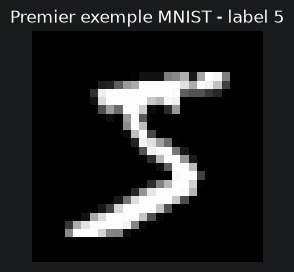

In [23]:
x_train, y_train, x_test, y_test = autoencoder.load_mnist()

print("\nPremière image - shape :", x_train[0].shape)

fig = plt.figure(figsize=(3, 3))
plt.imshow(autoencoder._to_display_image(x_train[0]), cmap="gray")
plt.title(f"Premier exemple MNIST - label {y_train[0]}")
plt.axis("off")
plt.show()


## 4. Architecture générée à partir de la configuration

Changer `CONFIG.architecture`, `hidden_dims`, `conv_filters`, `latent_dim`, etc. modifie automatiquement le modèle.


## 5. Entraînement

La boucle personnalisée réalise à chaque batch :

`X → Encoder → Z → Decoder → X_reconstructed → Loss → Backpropagation`


In [25]:
history = autoencoder.fit(x_train)



================ ENTRAÎNEMENT ================

--- CONFIGURATION ---
architecture       : dense
latent_dim         : 2
hidden_dims        : (128, 32)
hidden_activation  : relu
latent_activation  : linear
output_activation  : sigmoid
initializer        : glorot_uniform
optimizer          : adam
learning_rate      : 0.001
loss               : mse
batch_size         : 256
epochs             : 200
normalization      : zero_one
Epoch 01/200 - loss: 0.077397
Epoch 02/200 - loss: 0.056730
Epoch 03/200 - loss: 0.051776
Epoch 04/200 - loss: 0.049219
Epoch 05/200 - loss: 0.047578
Epoch 06/200 - loss: 0.046327
Epoch 07/200 - loss: 0.045304
Epoch 08/200 - loss: 0.044458
Epoch 09/200 - loss: 0.043740
Epoch 10/200 - loss: 0.043152
Epoch 11/200 - loss: 0.042627
Epoch 12/200 - loss: 0.042212
Epoch 13/200 - loss: 0.041821
Epoch 14/200 - loss: 0.041505
Epoch 15/200 - loss: 0.041220
Epoch 16/200 - loss: 0.040949
Epoch 17/200 - loss: 0.040709
Epoch 18/200 - loss: 0.040505
Epoch 19/200 - loss: 0.040300
E

## 6. Visualisation des reconstructions sur le jeu d'entraînement

Juste avant la courbe de loss, on vérifie visuellement ce que l'AutoEncodeur a appris sur quelques exemples du **train set**.

- Ligne 1 : images originales du train.
- Ligne 2 : reconstructions correspondantes.


Figure sauvegardée : outputs_autoencoder_mnist\01_train_reconstructions.png


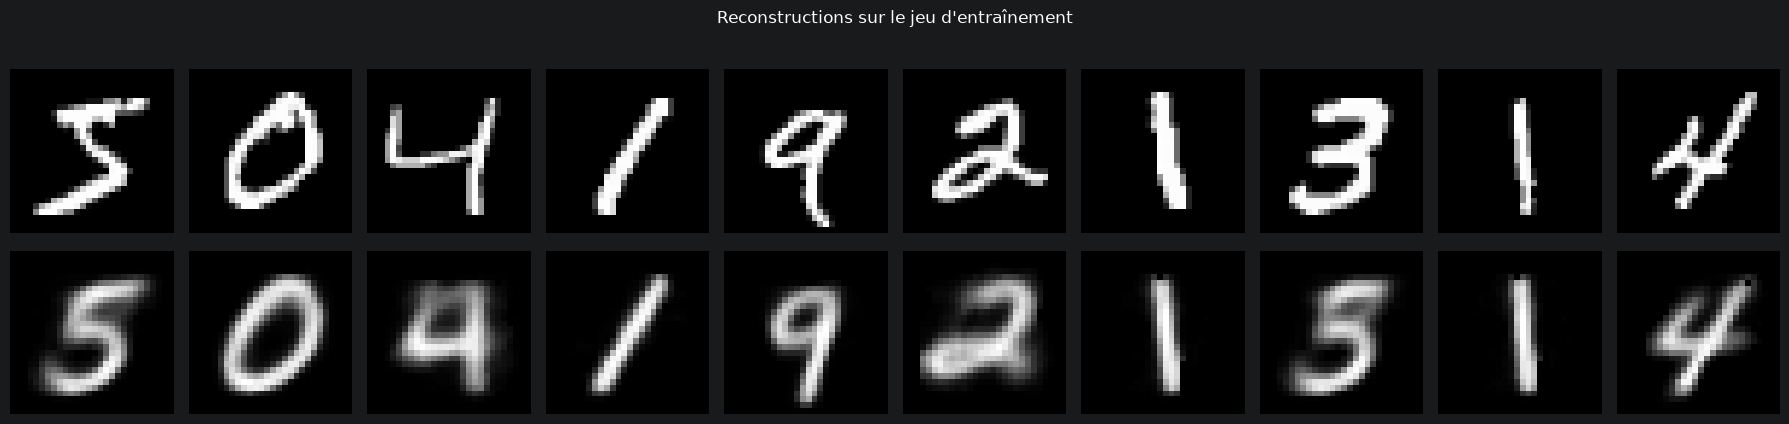

In [26]:
train_reconstructions, _ = autoencoder.plot_train_reconstructions(
    x_train
)


## 7. Évaluation et courbe de loss



Loss de reconstruction sur le test : 0.03792520612478256
Figure sauvegardée : outputs_autoencoder_mnist\02_training_loss.png


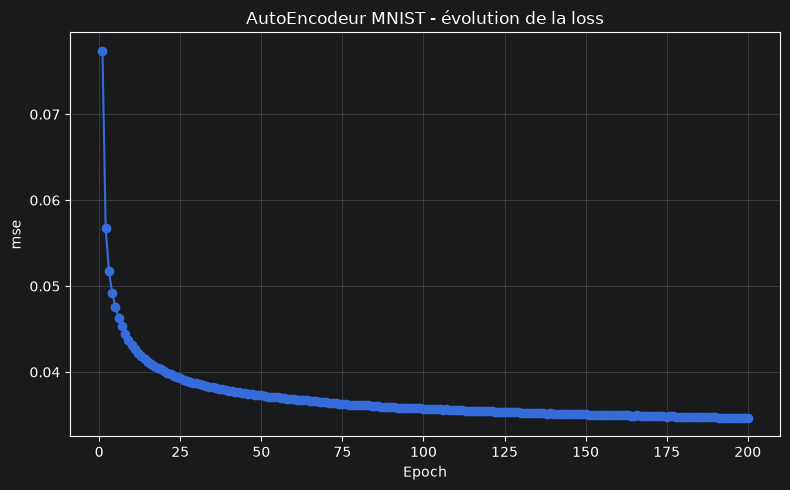

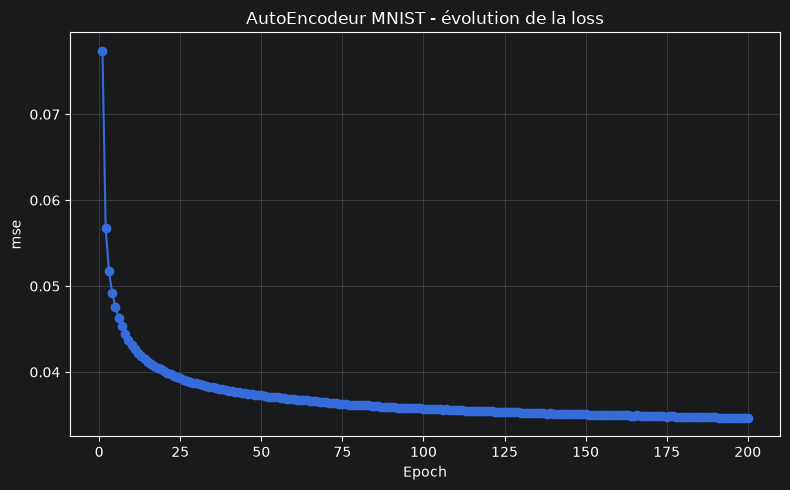

In [27]:
test_loss = autoencoder.evaluate(x_test)
autoencoder.plot_history()


## 8. Points latents et reconstructions après entraînement

Il ne s'agit pas d'une nouvelle tâche de compression/décompression.

Nous inspectons simplement ce que le forward pass appris produit maintenant :
- coordonnées latentes ;
- image originale ;
- reconstruction correspondante.



========== POINTS LATENTS APRÈS ENTRAÎNEMENT ==========
Latent shape : (10, 2)
Image 00 | y=7 | z=[-19.856  11.673]
Image 01 | y=2 | z=[0.059 0.99 ]
Image 02 | y=1 | z=[-5.728 36.602]
Image 03 | y=0 | z=[-3.556 -5.702]
Image 04 | y=4 | z=[-7.963  3.217]
Image 05 | y=1 | z=[-6.755 43.81 ]
Image 06 | y=4 | z=[-5.745  7.251]
Image 07 | y=9 | z=[-4.491  3.997]
Image 08 | y=5 | z=[-5.679  3.536]
Image 09 | y=9 | z=[-32.161  15.124]
Figure sauvegardée : outputs_autoencoder_mnist\03_points_latents_et_reconstructions.png


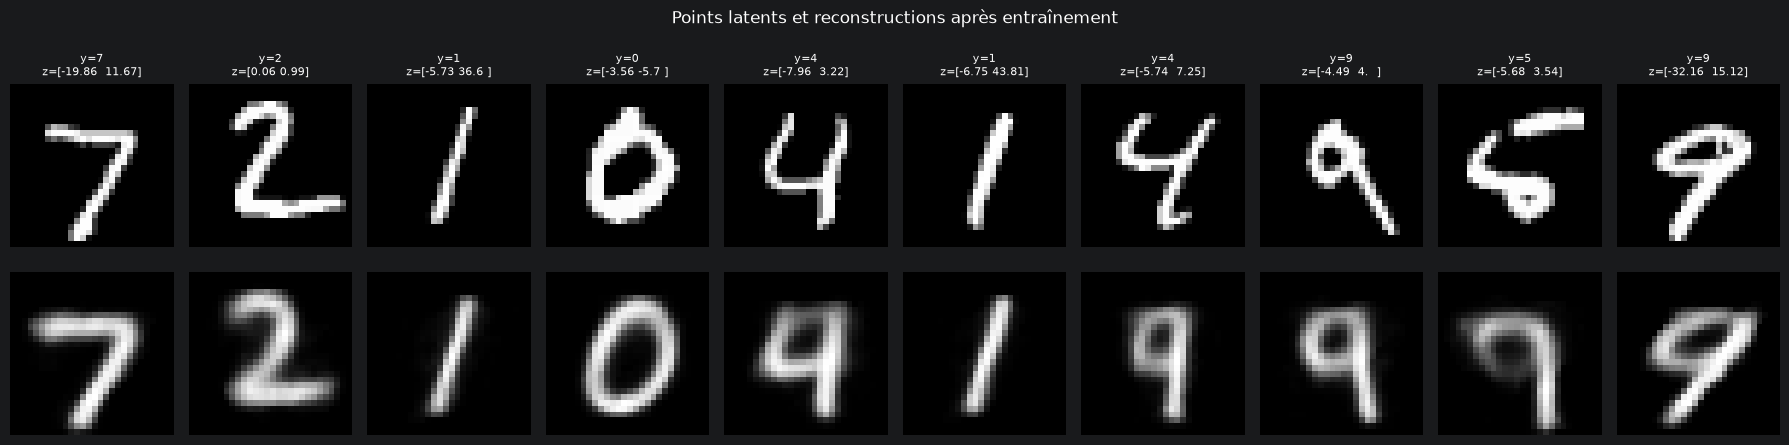

In [28]:
z_examples, reconstructed_examples, _ = (
    autoencoder.inspect_latent_and_reconstructions(
        x_test,
        y_test,
    )
)


## 9. Visualisation directe de l'espace latent

Cette cellule ne produit une carte directe que lorsque :

```python
CONFIG.latent_dim == 2
```

Avec un latent de dimension 8, 16 ou 32, il n'est pas possible d'afficher directement tout l'espace sur un plan 2D sans effectuer une projection supplémentaire.



========== VISUALISATION ESPACE LATENT ==========
z1 : [-37.515, 16.027]
z2 : [-13.507, 75.402]
Figure sauvegardée : outputs_autoencoder_mnist\04_visualisation_espace_latent.png


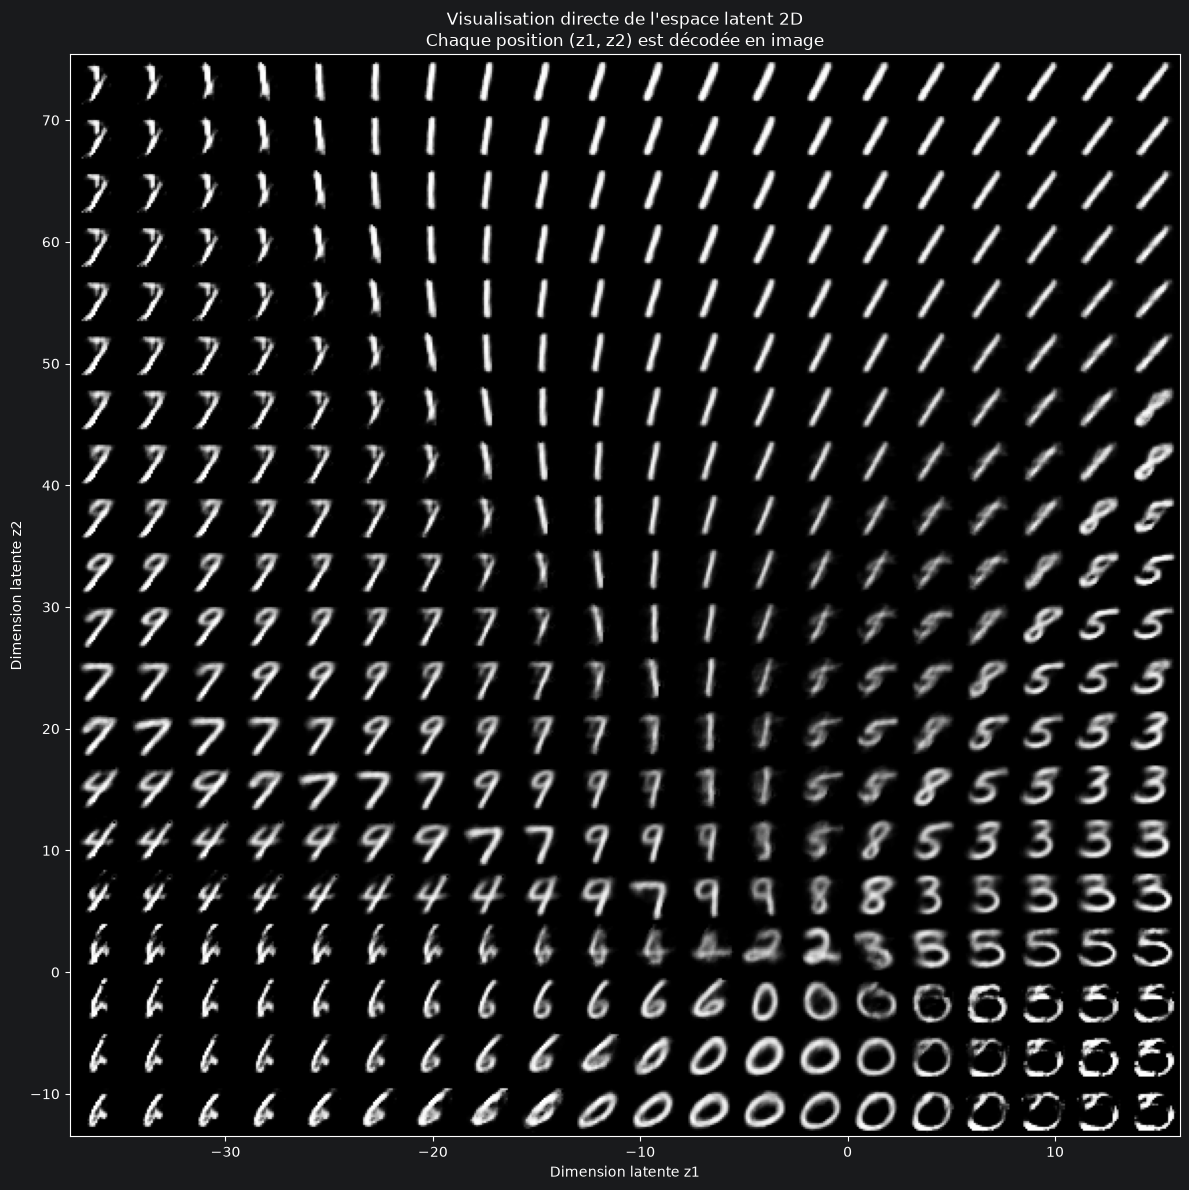

In [29]:
latent_visualization = autoencoder.visualize_latent_space(
    x_train
)


## 10. Génération expérimentale de nouvelles images

Pour un AutoEncodeur simple, la distribution du latent n'est pas régularisée comme dans un VAE.

Nous estimons donc la moyenne et la covariance des vrais codes latents, puis nous échantillonnons cette distribution empirique.



========== GÉNÉRATION DE NOUVELLES IMAGES ==========
Moyenne latente : [-4.7470026 10.292183 ]
Shape des points échantillonnés : (16, 2)
Figure sauvegardée : outputs_autoencoder_mnist\05_generation_images.png


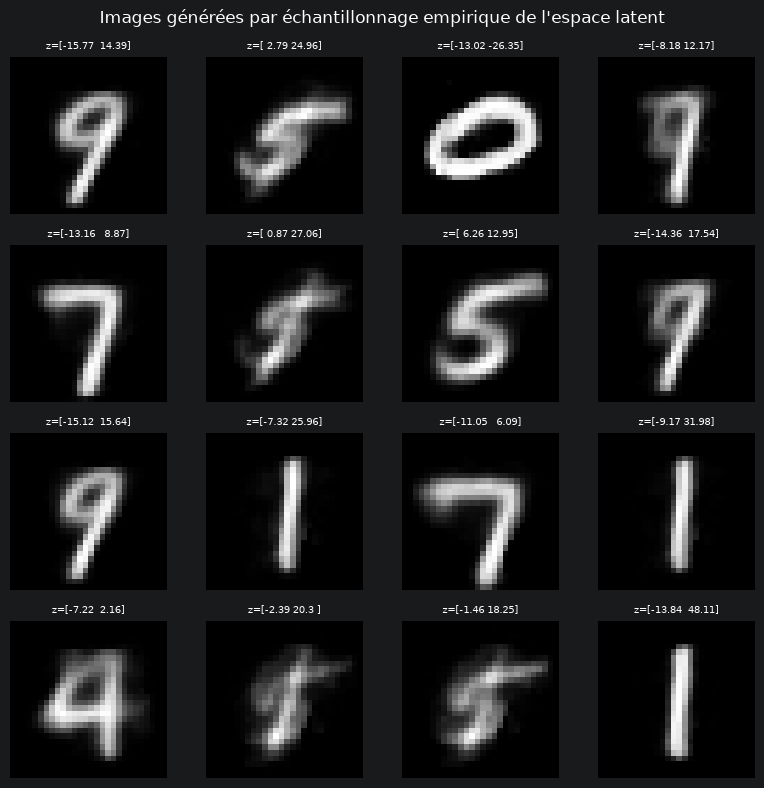

In [30]:
sampled_z, generated_images, _ = autoencoder.generate_images(
    x_train
)
